In [ ]:
!pip -q install librosa soundfile scikit-learn joblib

In [ ]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import drive
import os

# Ensure the mount point is completely clear
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    # Use a shell command to remove all contents within the mount point
    # This is a more aggressive cleanup than flush_and_unmount alone might provide.
    !rm -rf /content/drive/*

drive.flush_and_unmount() # Unmount if it was mounted previously in a problematic state
drive.mount('/content/drive', force_remount=True)
print("Google Drive mounted successfully.")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

SER_DIR = MYDRIVE / "SER_datasets"

print("SER_datasets exists:", SER_DIR.exists())
print("\nContents of SER_datasets:")

if SER_DIR.exists():
    for item in SER_DIR.iterdir():
        print(" -", item)
else:
    print("SER_datasets was not found.")

SER_datasets exists: True

Contents of SER_datasets:
 - /content/drive/MyDrive/SER_datasets/archive.zip
 - /content/drive/MyDrive/SER_datasets/t9h6p943xy-5.zip
 - /content/drive/MyDrive/SER_datasets/English_RAVDESS
 - /content/drive/MyDrive/SER_datasets/BanglaSer
 - /content/drive/MyDrive/SER_datasets/results
 - /content/drive/MyDrive/SER_datasets/models
 - /content/drive/MyDrive/SER_datasets/features


In [ ]:
import zipfile
from pathlib import Path

SER_DIR = Path("/content/drive/MyDrive/SER_datasets")

zip_files = list(SER_DIR.glob("*.zip"))

for zip_path in zip_files:
    print("\n" + "=" * 60)
    print("ZIP FILE:", zip_path.name)
    print("=" * 60)

    with zipfile.ZipFile(zip_path, "r") as z:
        files = z.namelist()

        print("Total items:", len(files))
        print("\nFirst 20 items:")

        for item in files[:20]:
            print(item)


ZIP FILE: archive.zip
Total items: 2880

First 20 items:
Actor_01/03-01-01-01-01-01-01.wav
Actor_01/03-01-01-01-01-02-01.wav
Actor_01/03-01-01-01-02-01-01.wav
Actor_01/03-01-01-01-02-02-01.wav
Actor_01/03-01-02-01-01-01-01.wav
Actor_01/03-01-02-01-01-02-01.wav
Actor_01/03-01-02-01-02-01-01.wav
Actor_01/03-01-02-01-02-02-01.wav
Actor_01/03-01-02-02-01-01-01.wav
Actor_01/03-01-02-02-01-02-01.wav
Actor_01/03-01-02-02-02-01-01.wav
Actor_01/03-01-02-02-02-02-01.wav
Actor_01/03-01-03-01-01-01-01.wav
Actor_01/03-01-03-01-01-02-01.wav
Actor_01/03-01-03-01-02-01-01.wav
Actor_01/03-01-03-01-02-02-01.wav
Actor_01/03-01-03-02-01-01-01.wav
Actor_01/03-01-03-02-01-02-01.wav
Actor_01/03-01-03-02-02-01-01.wav
Actor_01/03-01-03-02-02-02-01.wav

ZIP FILE: t9h6p943xy-5.zip
Total items: 1467

First 20 items:
t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-02-01.wav
t9h6p943xy-5/BanglaSER/Actor 01/03-01-02-01-01-01-01.wav
t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-03-01.wav
t9h6p943xy-5/BanglaSER/Actor

In [ ]:
import zipfile
from pathlib import Path

SER_DIR = Path("/content/drive/MyDrive/SER_datasets")
ZIP_PATH = SER_DIR / "t9h6p943xy-5.zip"

EXTRACT_DIR = SER_DIR / "BanglaSer"

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Bangla dataset extracted successfully.")
print("Location:")
print(EXTRACT_DIR)

Bangla dataset extracted successfully.
Location:
/content/drive/MyDrive/SER_datasets/BanglaSer


In [ ]:
print("Searching for Actor folders...\n")

actor_folders = sorted([
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_dir() and p.name.lower().startswith("actor")
])

print("Actor folders found:", len(actor_folders))

for folder in actor_folders[:30]:
    print(folder)

Searching for Actor folders...

Actor folders found: 34
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 02
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 03
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 04
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 05
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 06
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 07
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 08
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 09
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 10
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 11
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 12
/content

In [ ]:
audio_files = sorted(
    EXTRACT_DIR.rglob("*.wav")
)

print("Total WAV files:", len(audio_files))

print("\nFirst 10 files:")

for file in audio_files[:10]:
    print(file)

Total WAV files: 1467

First 10 files:
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-02-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-03-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-02-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-03-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-02-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-03-01.wav
/content/drive/MyDrive/SER_dataset

In [ ]:
BANGLA_DIR = actor_folders[0].parent

print("Bangla dataset path:")
print(BANGLA_DIR)

print("\nNumber of WAV files:", len(list(BANGLA_DIR.rglob("*.wav"))))

Bangla dataset path:
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER

Number of WAV files: 1467


In [ ]:
audio_extensions = {".wav", ".flac", ".ogg", ".mp3", ".m4a"}
audio_files = [
    p for p in BANGLA_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in audio_extensions
]
print("Total audio files found:", len(audio_files))
print("\nFirst 10 files:")
for file in audio_files[:10]:
    print(file)

Total audio files found: 1467

First 10 files:
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-03-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-02-01-01-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-03-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-02-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-02-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-01-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-03-01.wav
/content/drive/MyDrive/SER

In [ ]:
EMOTION_MAP = {
    1: "happy",
    2: "sad",
    3: "angry",
    4: "surprised",
    5: "neutral"
}

def extract_emotion_from_filename(file_path):
    filename = Path(file_path).stem
    parts = filename.split("-")
    if len(parts) != 7:
        return None
    try:
        emotion_code = int(parts[2])
    except ValueError:
        return None
    return EMOTION_MAP.get(emotion_code)

def extract_speaker_from_path(file_path):
    """
    Extract speaker from folders such as:
    Actor 01
    Actor 02
    etc.

    IMPORTANT: the speaker is read from the FOLDER, not from the
    filename's last field. One file in this dataset,
        Actor 19/03-01-05-01-01-03-03.wav
    ends in -03 by mistake, but it lives in Actor 19's folder and belongs
    to Actor 19. Trusting the folder fixes that automatically.
    """
    path = Path(file_path)
    for part in path.parts:
        match = re.fullmatch(r"Actor\s*(\d+)", part, re.IGNORECASE)
        if match:
            return f"Actor_{int(match.group(1)):02d}"
    # Backup: only if no Actor folder was found
    filename = path.stem
    parts = filename.split("-")
    if len(parts) == 7:
        try:
            speaker_code = int(parts[-1])
            return f"Actor_{speaker_code:02d}"
        except:
            pass
    return None

In [ ]:
test_files = [
    "03-01-01-01-01-01-01.wav",
    "03-01-02-01-01-01-01.wav",
    "03-01-03-01-01-01-01.wav",
    "03-01-05-01-01-01-01.wav"
]
for filename in test_files:
    print(
        filename,
        "→",
        extract_emotion_from_filename(filename)
    )

03-01-01-01-01-01-01.wav → happy
03-01-02-01-01-01-01.wav → sad
03-01-03-01-01-01-01.wav → angry
03-01-05-01-01-01-01.wav → neutral


In [ ]:
records = []
skipped = []
for file_path in audio_files:
    emotion = extract_emotion_from_filename(file_path)
    speaker = extract_speaker_from_path(file_path)
    if emotion is not None and speaker is not None:
        records.append({
            "file_path": str(file_path),
            "speaker": speaker,
            "emotion": emotion,
            "language": "Bangla"
        })
    else:
        skipped.append(str(file_path))

metadata = pd.DataFrame(records)
print("Valid audio files:", len(metadata))
print("Skipped files:", len(skipped))
for s in skipped[:10]:
    print("   skipped:", s)
print("\nDataset preview:")

Valid audio files: 1467
Skipped files: 0

Dataset preview:


In [ ]:
print("Number of recordings:", len(metadata))
print("Number of speakers:", metadata["speaker"].nunique())
print("Number of emotions:", metadata["emotion"].nunique())
print("\nEmotion classes:")
for emotion in sorted(metadata["emotion"].unique()):
    count = (metadata["emotion"] == emotion).sum()
    print(f"{emotion:10s}: {count}")
print("\nSpeakers:")
print(sorted(metadata["speaker"].unique()))

# Recordings per speaker: 27 speakers have 45, seven have 36.
print("\nRecordings per speaker:")
per_speaker = metadata.groupby("speaker").size()
print("min:", per_speaker.min(), " max:", per_speaker.max())
print("speakers with fewer files (no neutral recordings):")
print(sorted(per_speaker[per_speaker < per_speaker.max()].index))

Number of recordings: 1467
Number of speakers: 34
Number of emotions: 5

Emotion classes:
angry     : 306
happy     : 306
neutral   : 243
sad       : 306
surprised : 306

Speakers:
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24', 'Actor_25', 'Actor_26', 'Actor_27', 'Actor_28', 'Actor_29', 'Actor_30', 'Actor_31', 'Actor_32', 'Actor_33', 'Actor_34']

Recordings per speaker:
min: 36  max: 45
speakers with fewer files (no neutral recordings):
['Actor_11', 'Actor_12', 'Actor_13', 'Actor_16', 'Actor_18', 'Actor_20', 'Actor_29']


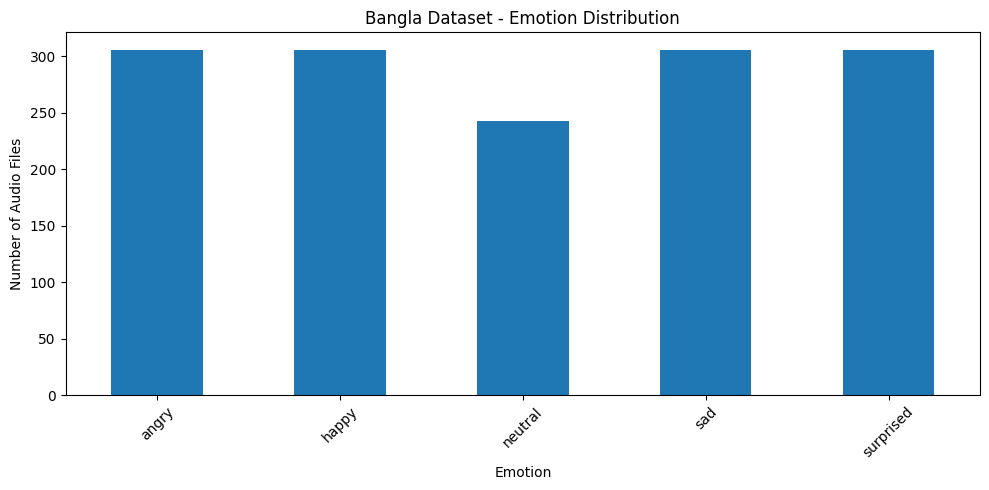

In [ ]:
from pathlib import Path

# Make sure the results folder exists (normally created in Cell 4)
RESULT_DIR = Path("/content/drive/MyDrive/SER_datasets/results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
metadata["emotion"].value_counts().sort_index().plot(kind="bar")
plt.title("Bangla Dataset - Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "bangla_emotion_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from collections import Counter
rates = Counter()
for fp in audio_files:
    info = sf.info(fp)
    rates[info.samplerate] += 1
print("Sample rates across the dataset:", dict(rates))

Sample rates across the dataset: {48000: 617, 44100: 850}


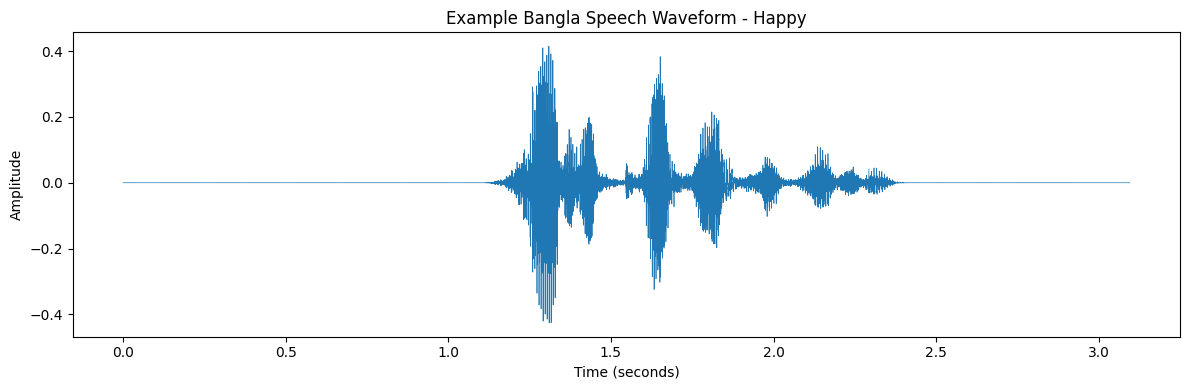

In [ ]:
import numpy as np

# Reload the audio directly so we don't depend on whatever `y` currently holds
y_plot, sr_plot = librosa.load(metadata.iloc[0]["file_path"], sr=16000, mono=True)
t = np.arange(len(y_plot)) / sr_plot

plt.figure(figsize=(12, 4))
plt.plot(t, y_plot, linewidth=0.5)
plt.title(f"Example Bangla Speech Waveform - {metadata.iloc[0]['emotion'].capitalize()}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [ ]:
TARGET_SR = 16000

def preprocess_audio(file_path, target_sr=TARGET_SR):
    y, sr = librosa.load(
        file_path,
        sr=target_sr,      # forces every file to the same rate
        mono=True          # BanglaSER has many stereo files; mix to mono
    )
    # Remove leading/trailing silence
    y, _ = librosa.effects.trim(
        y,
        top_db=30
    )
    # Normalize amplitude (removes device gain differences)
    max_value = np.max(np.abs(y))
    if max_value > 0:
        y = y / max_value
    return y, target_sr

In [ ]:
import numpy as np, librosa

# normally from Cell 14
TARGET_SR = 16000
def preprocess_audio(file_path, target_sr=TARGET_SR):
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    m = np.max(np.abs(y))
    if m > 0:
        y = y / m
    return y, target_sr

# normally from Cell 12
sample_path = metadata.iloc[0]["file_path"]

# your cell
y_processed, sr_processed = preprocess_audio(sample_path)
print("Processed sampling rate:", sr_processed)
print("Processed duration:",
      round(len(y_processed) / sr_processed, 2),
      "seconds")
print("Maximum amplitude:",
      round(np.max(np.abs(y_processed)), 4))

Processed sampling rate: 16000
Processed duration: 1.28 seconds
Maximum amplitude: 1.0


In [ ]:

def summarize_feature(feature):
    """
    Convert a variable-length feature matrix/vector
    into fixed-length statistics.
    """
    return np.hstack([
        np.mean(feature, axis=1),
        np.std(feature, axis=1)
    ])

def extract_features(file_path):
    y, sr = preprocess_audio(file_path)
    # Avoid errors with extremely short files
    if len(y) < 2048:
        raise ValueError("Audio file is too short.")
    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=1024,
        hop_length=512
    )
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(
        mfcc,
        order=2
    )
    # Chroma
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )
    # RMS
    rms = librosa.feature.rms(
        y=y,
        frame_length=1024,
        hop_length=512
    )
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=1024,
        hop_length=512
    )
    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )
    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )
    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )
    features = np.hstack([
        summarize_feature(mfcc),
        summarize_feature(delta_mfcc),
        summarize_feature(delta2_mfcc),
        summarize_feature(chroma),
        summarize_feature(rms),
        summarize_feature(zcr),
        summarize_feature(spectral_centroid),
        summarize_feature(spectral_bandwidth),
        summarize_feature(spectral_rolloff)
    ])
    return features


In [ ]:
sample_features = extract_features(sample_path)
print("Feature vector length:", len(sample_features))
print("First 20 values:")
print(sample_features[:20])

Feature vector length: 112
First 20 values:
[-332.48660278   72.89289093  -26.48517799    1.4319607     0.68811548
  -32.03863525  -39.55622482  -30.55709076  -17.57484818    4.76219273
  -21.12934303  -11.33782291  -15.14785576  115.50772858   60.09753036
   80.70340729   33.51276016   29.86318207   31.64128113   23.64914131]


In [ ]:
feature_rows = []
failed_files = []
print("Starting feature extraction...")
print("Total files:", len(metadata))
for i, row in metadata.iterrows():
    try:
        features = extract_features(row["file_path"])
        feature_rows.append({
            "file_path": row["file_path"],
            "speaker": row["speaker"],
            "emotion": row["emotion"],
            **{
                f"feature_{j}": value
                for j, value in enumerate(features)
            }
        })
    except Exception as e:
        failed_files.append({
            "file_path": row["file_path"],
            "error": str(e)
        })
    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/{len(metadata)} files"
        )
features_df = pd.DataFrame(feature_rows)
print("\nFeature extraction completed.")
print("Successful files:", len(features_df))
print("Failed files:", len(failed_files))

Starting feature extraction...
Total files: 1467
Processed 100/1467 files
Processed 200/1467 files
Processed 300/1467 files
Processed 400/1467 files
Processed 500/1467 files
Processed 600/1467 files
Processed 700/1467 files
Processed 800/1467 files
Processed 900/1467 files
Processed 1000/1467 files
Processed 1100/1467 files
Processed 1200/1467 files
Processed 1300/1467 files
Processed 1400/1467 files

Feature extraction completed.
Successful files: 1467
Failed files: 0


In [ ]:
print("Feature dataset shape:")
print(features_df.shape)
display(features_df.head())

Feature dataset shape:
(1467, 115)


,file_path,speaker,emotion,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111
0,/content/drive/MyDrive/SER_datasets/BanglaSer/...,Actor_01,happy,-332.486603,72.892891,-26.485178,1.431961,0.688115,-32.038635,-39.556225,...,0.092253,0.089599,0.171065,0.135204,1891.407435,1159.453809,1442.262211,509.983558,3065.929878,1832.523542
1,/content/drive/MyDrive/SER_datasets/BanglaSer/...,Actor_01,happy,-324.829559,156.897278,-5.417299,24.843636,14.652204,-40.397568,-16.072165,...,0.140614,0.107115,0.060969,0.023365,826.679571,268.310271,844.093294,321.228376,1586.993243,685.544483
2,/content/drive/MyDrive/SER_datasets/BanglaSer/...,Actor_01,sad,-302.025269,93.038391,43.531181,33.099640,15.850110,-5.566733,-24.597393,...,0.190592,0.124530,0.144894,0.205982,1621.888054,1632.777776,1307.775523,566.904360,2538.839286,2368.616219
3,/content/drive/MyDrive/SER_datasets/BanglaSer/...,Actor_01,happy,-321.113922,139.584991,5.799906,21.744738,20.771671,-39.447521,-10.973692,...,0.112510,0.065036,0.076172,0.067434,1147.256719,622.974353,1231.485126,496.406869,2104.967949,1168.410738
4,/content/drive/MyDrive/SER_datasets/BanglaSer/...,Actor_01,happy,-284.634827,94.066689,-23.014446,20.671574,9.666325,-32.424324,-28.437588,...,0.134187,0.099198,0.128380,0.145456,1644.563478,1099.983691,1419.047215,647.829488,2989.983974,1905.019724


In [ ]:
feature_columns = [
    col for col in features_df.columns
    if col.startswith("feature_")
]
X_all = features_df[feature_columns].values
print("NaN values:", np.isnan(X_all).sum())
print("Infinite values:", np.isinf(X_all).sum())
print("Feature count:", X_all.shape[1])

NaN values: 0
Infinite values: 0
Feature count: 112


In [ ]:
from pathlib import Path

FEATURE_DIR = SER_DIR / "features"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

feature_csv = FEATURE_DIR / "Bangla_features.csv"
features_df.to_csv(
    feature_csv,
    index=False
)
print("Feature dataset saved to:")
print(feature_csv)

Feature dataset saved to:
/content/drive/MyDrive/SER_datasets/features/Bangla_features.csv


In [ ]:
X = features_df[feature_columns].values
y = features_df["emotion"].values
groups = features_df["speaker"].values
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of speakers:", len(np.unique(groups)))

X shape: (1467, 112)
y shape: (1467,)
Number of speakers: 34


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Emotion encoding:")
for number, emotion in enumerate(label_encoder.classes_):
    print(number, "→", emotion)

Emotion encoding:
0 → angry
1 → happy
2 → neutral
3 → sad
4 → surprised


In [ ]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)
train_idx, test_idx = next(
    gss.split(
        X,
        y_encoded,
        groups=groups
    )
)
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]
print("Training recordings:", len(X_train))
print("Testing recordings:", len(X_test))
print("\nTraining speakers:")
print(sorted(np.unique(groups_train)))
print("\nTesting speakers:")
print(sorted(np.unique(groups_test)))
print(
    "\nCommon speakers:",
    set(groups_train) & set(groups_test)
)


Training recordings: 1170
Testing recordings: 297

Training speakers:
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_21', 'Actor_23', 'Actor_24', 'Actor_26', 'Actor_29', 'Actor_30', 'Actor_31', 'Actor_32', 'Actor_33', 'Actor_34']

Testing speakers:
['Actor_09', 'Actor_16', 'Actor_20', 'Actor_22', 'Actor_25', 'Actor_27', 'Actor_28']

Common speakers: set()


In [ ]:
print("Training class distribution:")
train_emotions = label_encoder.inverse_transform(y_train)
print(
    pd.Series(train_emotions).value_counts().sort_index()
)
print("\nTest class distribution:")
test_emotions = label_encoder.inverse_transform(y_test)
print(
    pd.Series(test_emotions).value_counts().sort_index()
)

Training class distribution:
angry        243
happy        243
neutral      198
sad          243
surprised    243
Name: count, dtype: int64

Test class distribution:
angry        63
happy        63
neutral      45
sad          63
surprised    63
Name: count, dtype: int64


In [ ]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)
train_sub_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=groups_train
    )
)
X_train_final = X_train[train_sub_idx]
X_val = X_train[val_idx]
y_train_final = y_train[train_sub_idx]
y_val = y_train[val_idx]
groups_train_final = groups_train[train_sub_idx]
groups_val = groups_train[val_idx]
print("Training:", len(X_train_final))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print(
    "\nTraining/Validation common speakers:",
    set(groups_train_final) & set(groups_val)
)
print(
    "Training/Test common speakers:",
    set(groups_train_final) & set(groups_test)
)
print(
    "Validation/Test common speakers:",
    set(groups_val) & set(groups_test)
)


Training: 927
Validation: 243
Test: 297

Training/Validation common speakers: set()
Training/Test common speakers: set()
Validation/Test common speakers: set()


In [ ]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ])
}

In [ ]:
baseline_results = []
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(
        X_train_final,
        y_train_final
    )
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(
        y_val,
        y_pred
    )
    precision = precision_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })
    trained_models[name] = model
baseline_results_df = pd.DataFrame(
    baseline_results
).sort_values(
    "Macro F1",
    ascending=False
)
display(baseline_results_df)


Training KNN...

Training Decision Tree...

Training Random Forest...

Training SVM...


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,Random Forest,0.518519,0.549685,0.551852,0.521395
3,SVM,0.514403,0.526653,0.533333,0.515554
0,KNN,0.407407,0.418703,0.440741,0.406459
1,Decision Tree,0.378601,0.380648,0.377778,0.375575


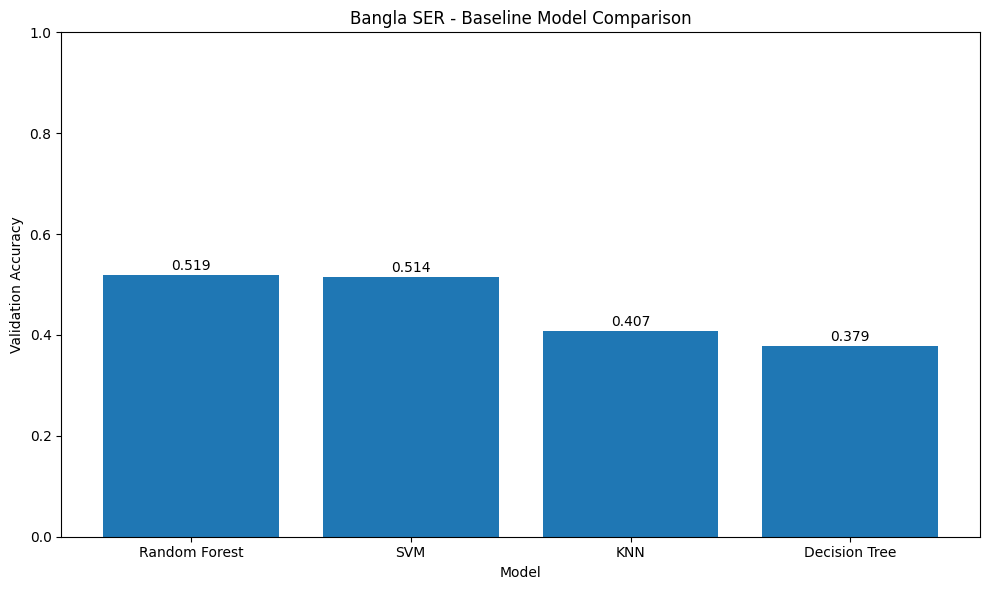

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(
    baseline_results_df["Model"],
    baseline_results_df["Accuracy"]
)
plt.ylabel("Validation Accuracy")
plt.xlabel("Model")
plt.title("Bangla SER - Baseline Model Comparison")
plt.ylim(0, 1)
for i, value in enumerate(
    baseline_results_df["Accuracy"]
):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "bangla_baseline_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
top_models = (
    baseline_results_df
    .sort_values("Macro F1", ascending=False)
    .head(2)["Model"]
    .tolist()
)
print("Models selected for tuning:")
for model in top_models:
    print("-", model)

Models selected for tuning:
- Random Forest
- SVM


In [ ]:
param_grids = {
    "SVM": {
        "classifier__C": [1, 10, 50],
        "classifier__gamma": ["scale", 0.01, 0.001],
        "classifier__kernel": ["rbf"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5]
    },
    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9],
        "classifier__weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "classifier__max_depth": [None, 5, 10, 20],
        "classifier__min_samples_split": [2, 5, 10]
    }
}

In [ ]:
tuned_models = {}
tuning_results = []
unique_train_speakers = np.unique(groups_train_final)
n_splits = min(
    5,
    len(unique_train_speakers)
)
group_cv = GroupKFold(
    n_splits=n_splits
)
for name in top_models:
    print(f"\nTuning {name}...")
    grid_search = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=group_cv,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(
        X_train_final,
        y_train_final,
        groups=groups_train_final
    )
    tuned_models[name] = grid_search.best_estimator_
    val_pred = grid_search.best_estimator_.predict(
        X_val
    )
    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )
    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )
    tuning_results.append({
        "Model": name,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": val_f1,
        "Best Parameters": grid_search.best_params_
    })
    print("Best parameters:")
    print(grid_search.best_params_)
tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df)


Tuning Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Tuning SVM...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters:
{'classifier__C': 10, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}


,Model,Validation Accuracy,Validation Macro F1,Best Parameters
0,Random Forest,0.522634,0.523445,"{'classifier__max_depth': 10, 'classifier__min..."
1,SVM,0.506173,0.501187,"{'classifier__C': 10, 'classifier__gamma': 0.0..."


In [ ]:
all_candidates = []
for name, model in trained_models.items():
    pred = model.predict(X_val)
    all_candidates.append({
        "Model": name,
        "Type": "Baseline",
        "Accuracy": accuracy_score(y_val, pred),
        "Macro F1": f1_score(
            y_val,
            pred,
            average="macro",
            zero_division=0
        ),
        "Model Object": model
    })
for name, model in tuned_models.items():
    pred = model.predict(X_val)
    all_candidates.append({
        "Model": name,
        "Type": "Tuned",
        "Accuracy": accuracy_score(y_val, pred),
        "Macro F1": f1_score(
            y_val,
            pred,
            average="macro",
            zero_division=0
        ),
        "Model Object": model
    })
candidate_df = pd.DataFrame(all_candidates)
candidate_df = candidate_df.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)
display(
    candidate_df[
        ["Model", "Type", "Accuracy", "Macro F1"]
    ]
)
best_model_name = candidate_df.iloc[0]["Model"]
best_model_type = candidate_df.iloc[0]["Type"]
best_model = candidate_df.iloc[0]["Model Object"]
print("\nSelected model:", best_model_name)
print("Model type:", best_model_type)

,Model,Type,Accuracy,Macro F1
0,Random Forest,Tuned,0.522634,0.523445
1,Random Forest,Baseline,0.518519,0.521395
2,SVM,Baseline,0.514403,0.515554
3,SVM,Tuned,0.506173,0.501187
4,KNN,Baseline,0.407407,0.406459
5,Decision Tree,Baseline,0.378601,0.375575



Selected model: Random Forest
Model type: Tuned


In [ ]:
X_train_complete = np.concatenate(
    [X_train_final, X_val],
    axis=0
)
y_train_complete = np.concatenate(
    [y_train_final, y_val],
    axis=0
)
groups_train_complete = np.concatenate(
    [groups_train_final, groups_val],
    axis=0
)
print("Final training recordings:",
      len(X_train_complete))
print("Final test recordings:",
      len(X_test))
print(
    "Train/Test speaker overlap:",
    set(groups_train_complete) & set(groups_test)
)

Final training recordings: 1170
Final test recordings: 297
Train/Test speaker overlap: set()


In [ ]:
final_model = best_model
final_model.fit(
    X_train_complete,
    y_train_complete
)
print("Final model trained successfully.")

Final model trained successfully.


In [ ]:
y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)
test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)
test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)
test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)
print("========================================")
print("FINAL BANGLA SER RESULTS")
print("========================================")
print(f"Model:           {best_model_name}")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1:        {test_f1:.4f}")
print("========================================")

FINAL BANGLA SER RESULTS
Model:           Random Forest
Accuracy:        0.5488
Macro Precision: 0.5483
Macro Recall:    0.5517
Macro F1:        0.5493


In [ ]:
target_names = label_encoder.classes_
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

       angry     0.7778    0.7778    0.7778        63
       happy     0.5571    0.6190    0.5865        63
     neutral     0.5870    0.6000    0.5934        45
         sad     0.4545    0.3968    0.4237        63
   surprised     0.3651    0.3651    0.3651        63

    accuracy                         0.5488       297
   macro avg     0.5483    0.5517    0.5493       297
weighted avg     0.5460    0.5488    0.5466       297



<Figure size 900x800 with 0 Axes>

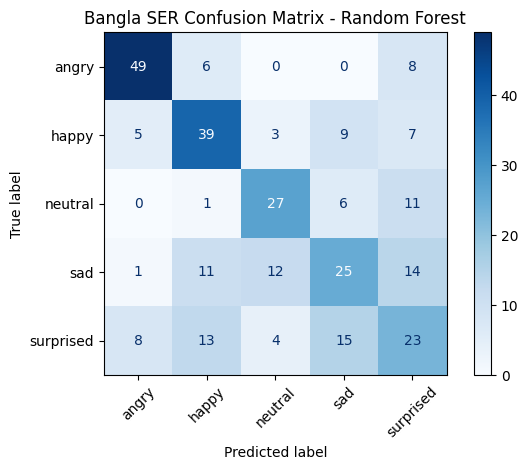

In [ ]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)
plt.figure(figsize=(9, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(
    cmap="Blues",
    xticks_rotation=45
)
plt.title(
    f"Bangla SER Confusion Matrix - {best_model_name}"
)
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "bangla_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from pathlib import Path

# Make sure the model directory exists
MODEL_DIR = SER_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

bangla_model_path = MODEL_DIR / "bangla_ser_model.pkl"
bangla_encoder_path = MODEL_DIR / "bangla_label_encoder.pkl"
joblib.dump(
    final_model,
    bangla_model_path
)
joblib.dump(
    label_encoder,
    bangla_encoder_path
)
print("Model saved:")
print(bangla_model_path)
print("\nLabel encoder saved:")
print(bangla_encoder_path)

Model saved:
/content/drive/MyDrive/SER_datasets/models/bangla_ser_model.pkl

Label encoder saved:
/content/drive/MyDrive/SER_datasets/models/bangla_label_encoder.pkl


In [ ]:

final_results = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Value": [
        best_model_name,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})
final_results.to_csv(
    RESULT_DIR / "bangla_final_results.csv",
    index=False
)
display(final_results)


,Metric,Value
0,Model,Random Forest
1,Accuracy,0.548822
2,Macro Precision,0.5483
3,Macro Recall,0.551746
4,Macro F1,0.549292


In [ ]:
def predict_emotion(audio_path):
    features = extract_features(audio_path)
    features = features.reshape(1, -1)
    prediction_encoded = final_model.predict(
        features
    )[0]
    emotion = label_encoder.inverse_transform(
        [prediction_encoded]
    )[0]
    result = {
        "emotion": emotion
    }
    # SVC provides probabilities because
    # probability=True was used.
    if hasattr(final_model, "predict_proba"):
        probabilities = final_model.predict_proba(
            features
        )[0]
        classes = label_encoder.inverse_transform(
            np.arange(len(probabilities))
        )
        probability_dict = {
            emotion_name: float(probability)
            for emotion_name, probability
            in zip(classes, probabilities)
        }
        result["probabilities"] = probability_dict
    return result

In [ ]:
test_example_index = test_idx[0]
test_example_path = metadata.iloc[
    test_example_index
]["file_path"]
actual_emotion = metadata.iloc[
    test_example_index
]["emotion"]
prediction_result = predict_emotion(
    test_example_path
)
print("========================================")
print("BANGLA SPEECH EMOTION RECOGNITION")
print("========================================")
print("Audio:")
print(test_example_path)
print("\nActual emotion:")
print(actual_emotion)
print("\nPredicted emotion:")
print(prediction_result["emotion"])
if "probabilities" in prediction_result:
    print("\nClass probabilities:")
    for emotion, probability in sorted(
        prediction_result["probabilities"].items(),
        key=lambda x: x[1],
        reverse=True
    ):
        print(
            f"{emotion:10s}: {probability * 100:.2f}%"
        )
print("========================================")


BANGLA SPEECH EMOTION RECOGNITION
Audio:
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 09/03-01-01-01-02-01-09.wav

Actual emotion:
happy

Predicted emotion:
happy

Class probabilities:
happy     : 30.76%
surprised : 18.67%
neutral   : 18.12%
sad       : 17.74%
angry     : 14.70%


In [ ]:
from google.colab import files
print("Upload a Bangla speech audio file.")
uploaded = files.upload()

Upload a Bangla speech audio file.


Saving 03-01-03-02-01-03-30.wav to 03-01-03-02-01-03-30.wav


In [ ]:
uploaded_filename = list(uploaded.keys())[0]
print("Uploaded file:")
print(uploaded_filename)

Uploaded file:
03-01-03-02-01-03-30.wav


In [ ]:
result = predict_emotion(
    uploaded_filename
)
print("\n========================================")
print("       SPEECH EMOTION RECOGNITION")
print("========================================")
print("Language: Bangla")
print("Audio:", uploaded_filename)
print("\nPredicted Emotion:")
print(result["emotion"].upper())
if "probabilities" in result:
    print("\nClass probabilities:")
    for emotion, probability in sorted(
        result["probabilities"].items(),
        key=lambda x: x[1],
        reverse=True
    ):
        print(
            f"{emotion.capitalize():10s} "
            f"{probability * 100:.2f}%"
        )
print("========================================")



       SPEECH EMOTION RECOGNITION
Language: Bangla
Audio: 03-01-03-02-01-03-30.wav

Predicted Emotion:
ANGRY

Class probabilities:
Angry      86.00%
Happy      5.02%
Surprised  4.66%
Sad        2.17%
Neutral    2.14%


In [ ]:
from IPython.display import Audio, display
display(
    Audio(
        uploaded_filename
    )
)

In [ ]:
print("==============================================")
print("       BANGLA SPEECH EMOTION RECOGNITION")
print("==============================================")
print(f"Total recordings:     {len(metadata)}")
print(f"Total speakers:       {metadata['speaker'].nunique()}")
print(f"Emotion classes:      {metadata['emotion'].nunique()}")
print("\nEmotion classes:")
print(", ".join(label_encoder.classes_))
print("\nFinal model:")
print(best_model_name)
print("\nFinal test performance:")
print(f"Accuracy:        {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {test_precision * 100:.2f}%")
print(f"Macro Recall:    {test_recall * 100:.2f}%")
print(f"Macro F1:        {test_f1 * 100:.2f}%")
print("\nSpeaker-independent testing: YES")
print("Feature extraction: MFCC + acoustic features")
print("==============================================")


       BANGLA SPEECH EMOTION RECOGNITION
Total recordings:     1467
Total speakers:       34
Emotion classes:      5

Emotion classes:
angry, happy, neutral, sad, surprised

Final model:
Random Forest

Final test performance:
Accuracy:        54.88%
Macro Precision: 54.83%
Macro Recall:    55.17%
Macro F1:        54.93%

Speaker-independent testing: YES
Feature extraction: MFCC + acoustic features
